# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Putu Nadya Putri Astina
- Email: nadyaputriast@gmail.com
- Id Dicoding: nadyaputriast

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install scikit-optimize

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from skopt import BayesSearchCV
from skopt.space import Integer, Categorical, Real
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

import joblib

### Menyiapkan data yang akan digunakan

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Proyek Student Performance Submission Kedua [Dicoding]/students_performance.csv", sep=";")
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

### Mengecek Informasi Dasar & *Missing Values*

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(0)

### Mengecek Sebaran Data

In [8]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### Melihat Korelasi

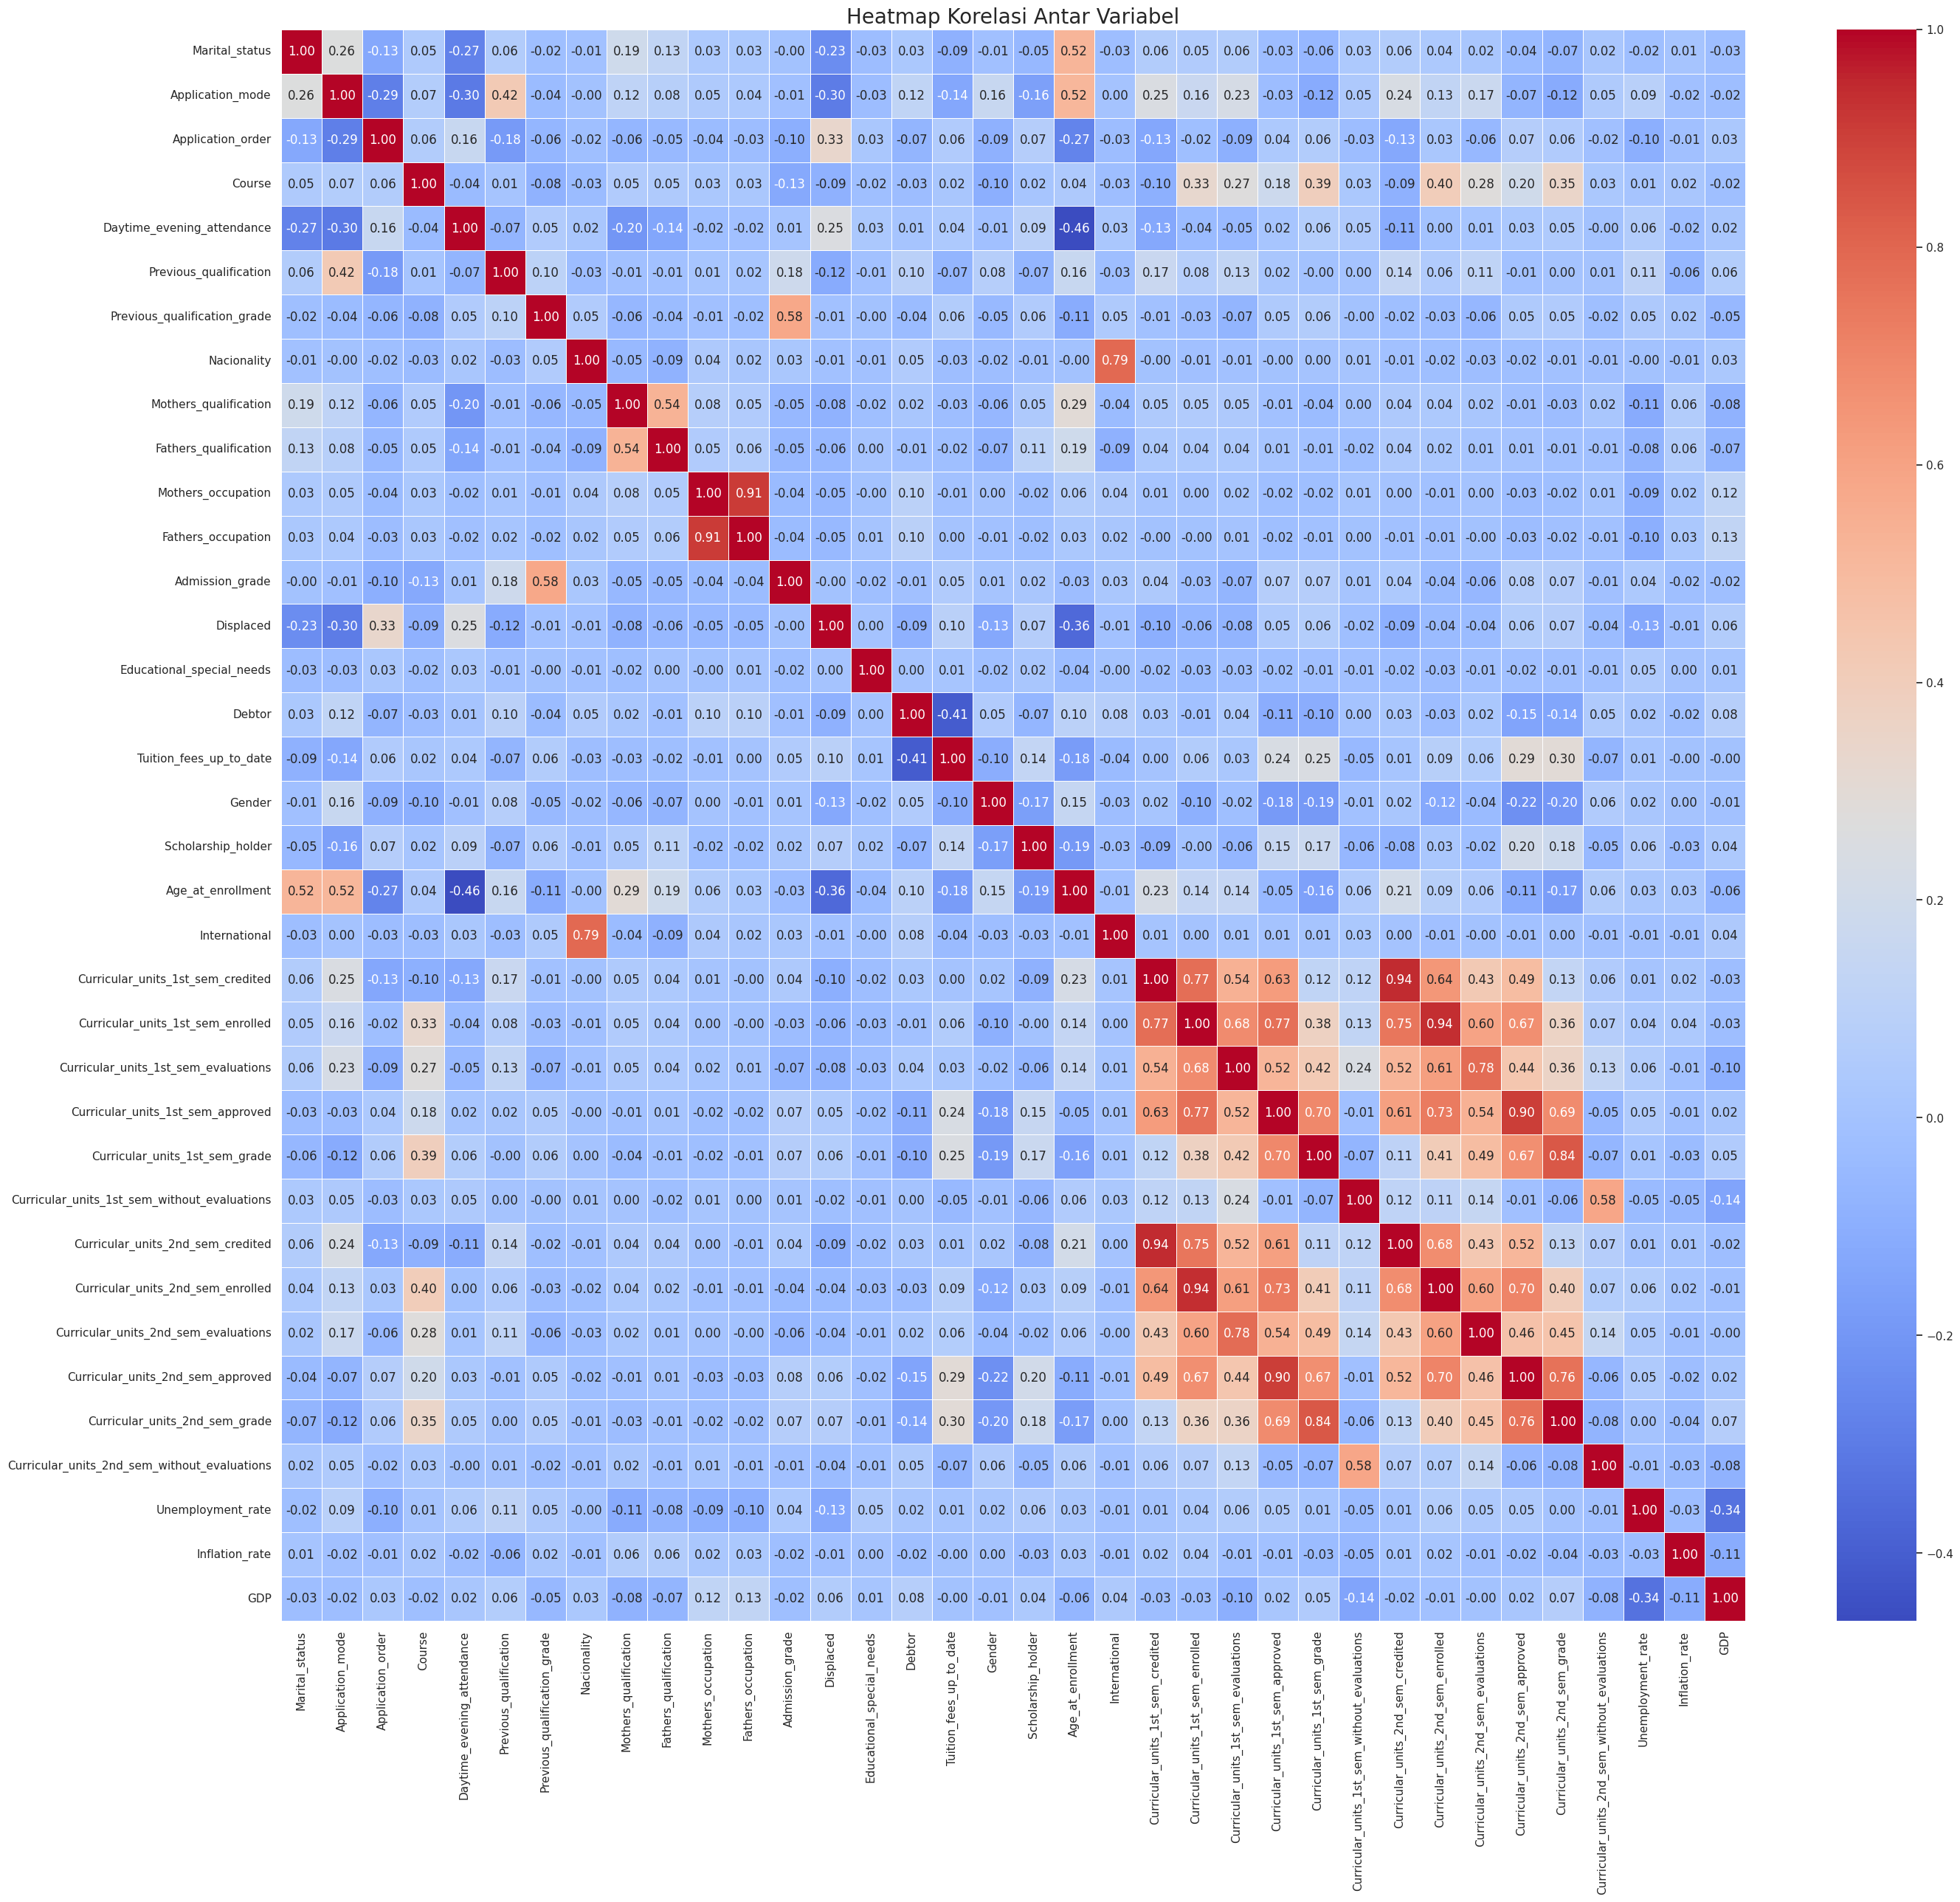

In [9]:
plt.figure(figsize=(32, 28))

correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap Korelasi Antar Variabel", fontsize=20)
plt.show()

## Exploratory Data Analysis (EDA)

### Analisis Univariat: Distribusi Profil Demografi dan Finansial Mahasiswa

/tmp/ipykernel_8802/1382208645.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='muted', ax=axes[i])
/tmp/ipykernel_8802/1382208645.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='muted', ax=axes[i])
/tmp/ipykernel_8802/1382208645.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='muted', ax=axes[i])
/tmp/ipykernel_8802/1382208645.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the 

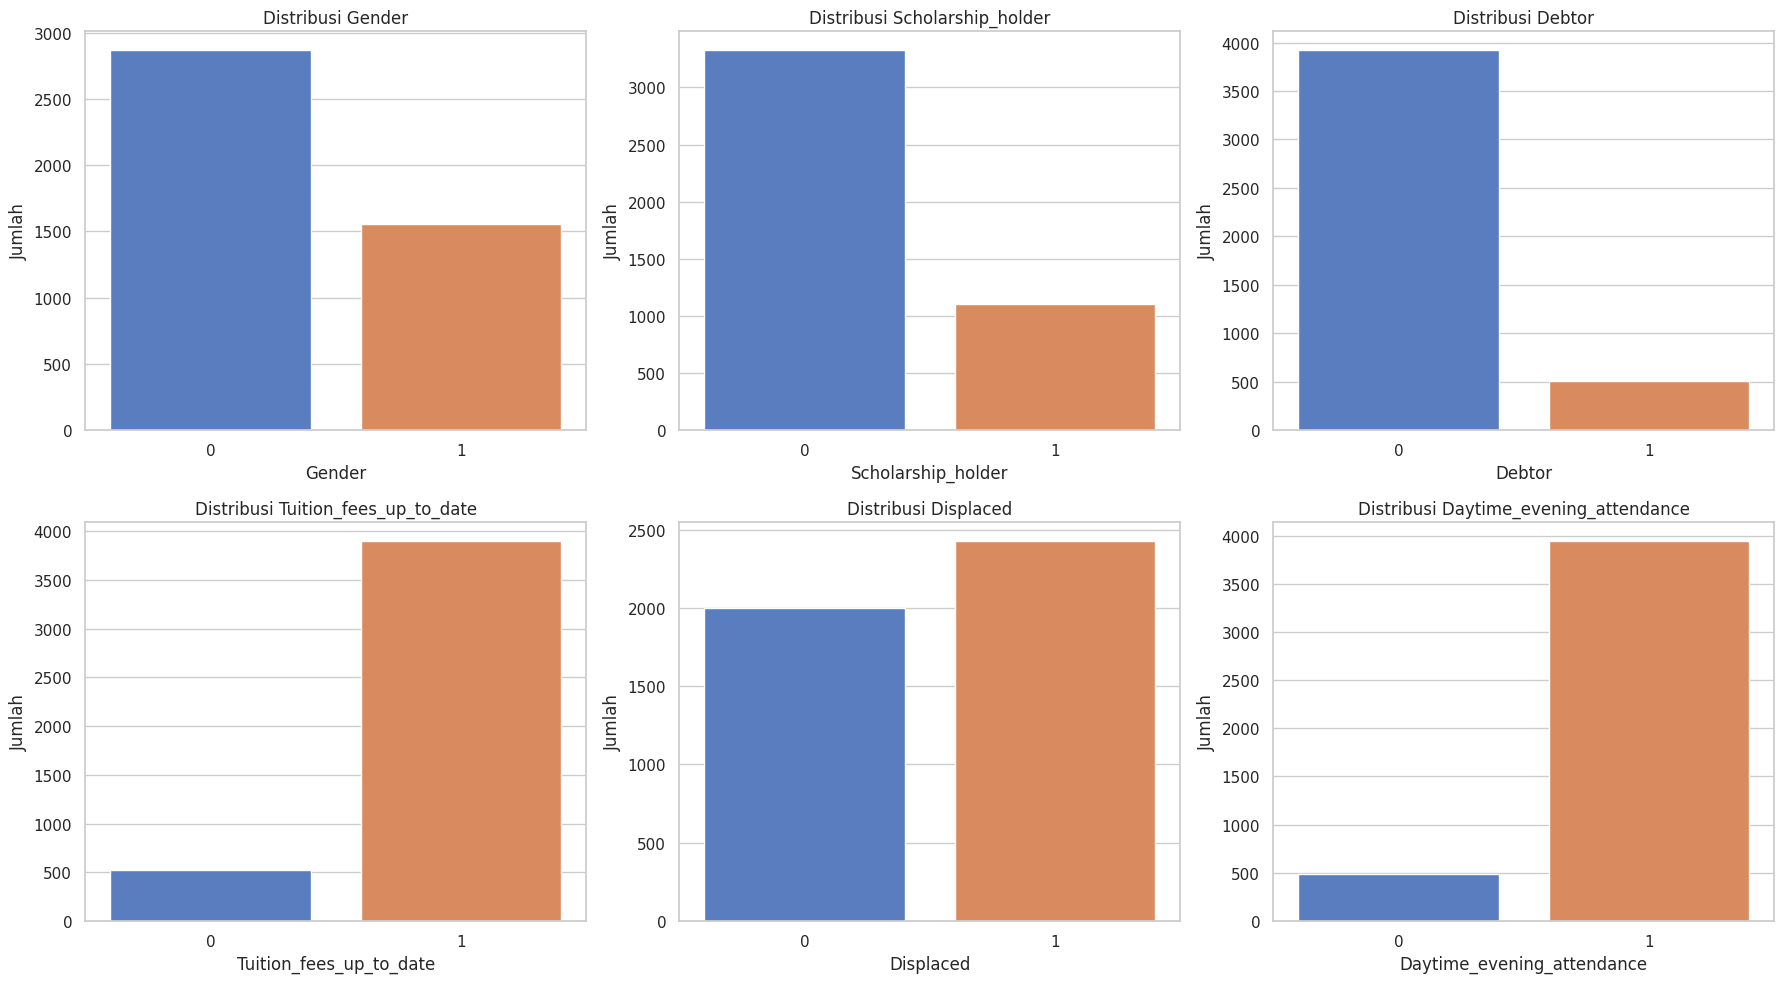

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

cat_cols = ['Gender', 'Scholarship_holder', 'Debtor',
            'Tuition_fees_up_to_date', 'Displaced', 'Daytime_evening_attendance']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, palette='muted', ax=axes[i])
    axes[i].set_title(f'Distribusi {col}', fontsize=12)
    axes[i].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

Visualisasi di atas menampilkan enam grafik batang yang menggambarkan distribusi keseluruhan profil mahasiswa Jaya Jaya Institut berdasarkan faktor demografi, finansial, dan waktu perkuliahan. Melalui kumpulan grafik ini, kita dapat memahami porsi latar belakang mahasiswa secara umum sebelum mengaitkannya dengan tingkat kelulusan atau *dropout*.

Dari sisi kesiapan finansial, terlihat pola yang cukup positif dimana mayoritas mahasiswa tercatat tidak memiliki utang akademik dan sangat disiplin dalam melunasi biaya kuliah (SPP) tepat waktu. Meskipun begitu, sangat disayangkan bahwa sebagian besar dari mereka harus membiayai kuliahnya sendiri karena kelompok mahasiswa yang tidak menerima beasiswa jauh lebih mendominasi dibandingkan yang menerima beasiswa. Sementara itu, dari sudut pandang demografi dan operasional kampus, profil pendaftar didominasi oleh mahasiswa perempuan dan mahasiswa yang berstatus pendatang (*displaced*), serta sebagian besar dari mereka lebih memilih untuk mengikuti kegiatan perkuliahan reguler pada siang hari dibandingkan kelas malam.

### Analisis Bivariat: Pengaruh Profil Demografi dan Finansial terhadap Status Kelulusan

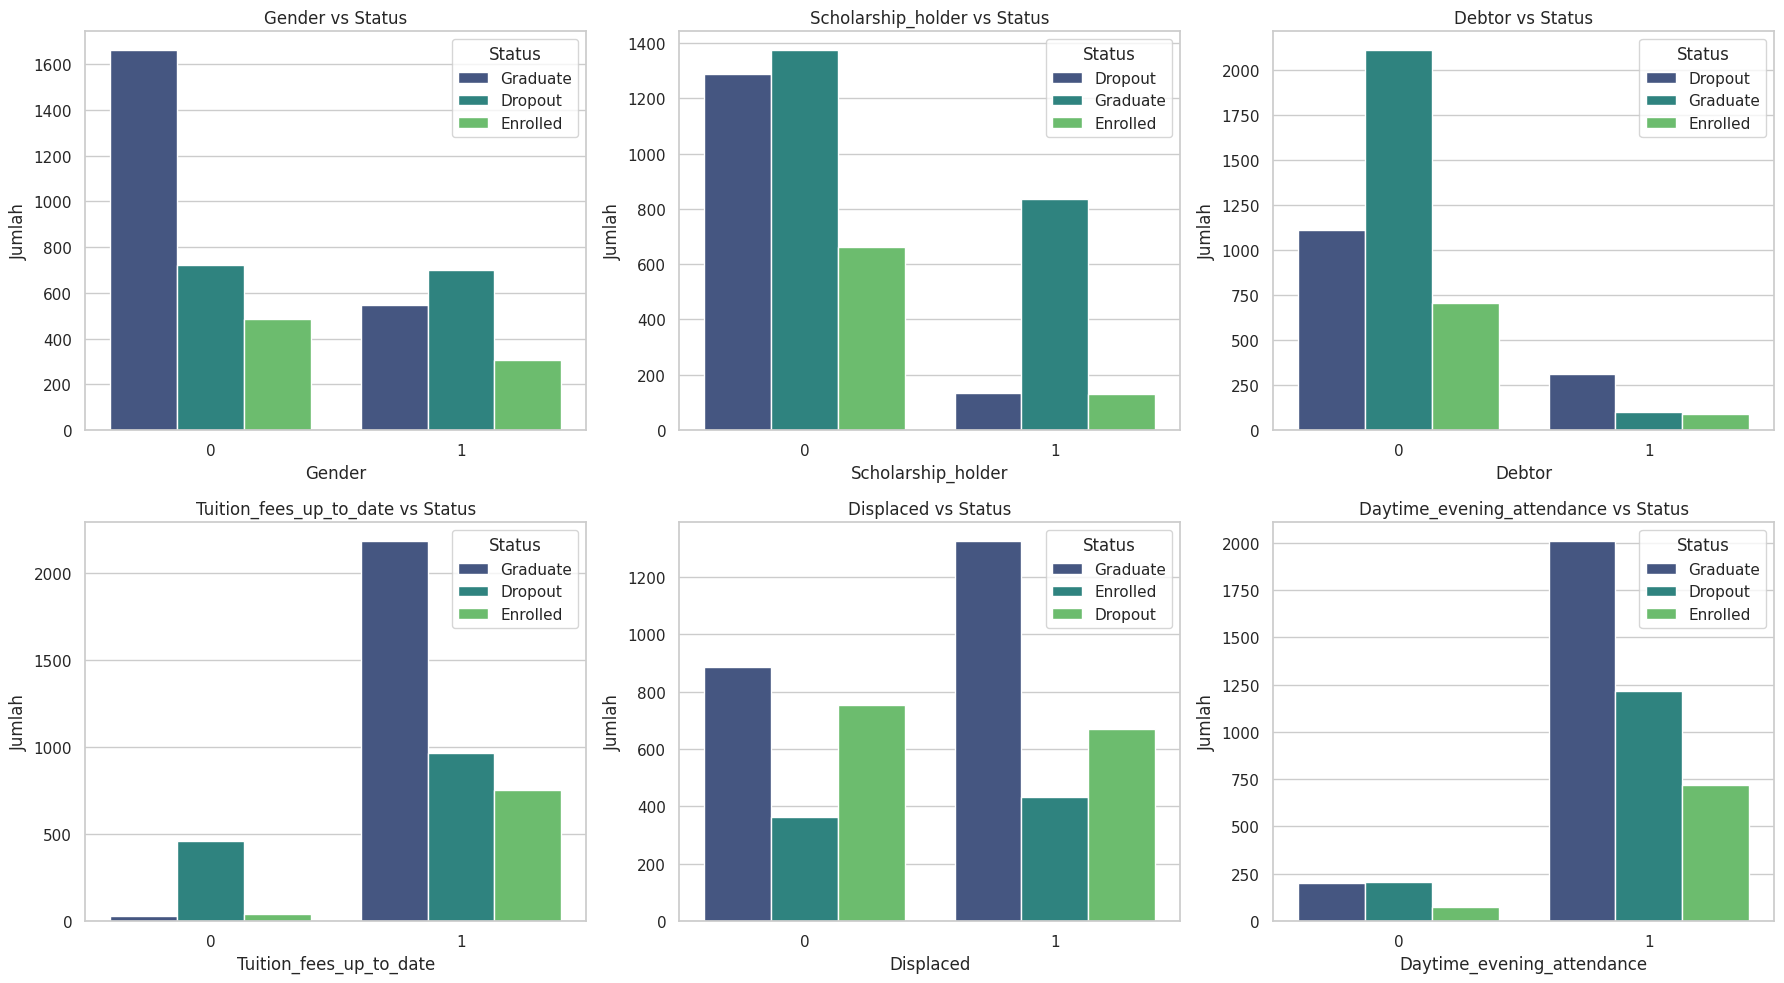

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Status', palette='viridis', ax=axes[i])
    axes[i].set_title(f'{col} vs Status', fontsize=12)
    axes[i].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

Visualisasi di atas memperlihatkan kaitan langsung antara latar belakang mahasiswa dengan probabilitas mereka untuk lulus atau mengalami *dropout*. Dari aspek finansial, terlihat pola yang sangat tegas dan menjadi temuan krusial bagi institusi: mahasiswa yang tidak memiliki beasiswa, memiliki catatan utang (*debtor*), dan menunggak pembayaran SPP memiliki tingkat *dropout* yang sangat tinggi, bahkan melampaui jumlah mereka yang berhasil lulus. Hal ini membuktikan bahwa kendala ekonomi merupakan salah satu pemicu utama kegagalan studi di Jaya Jaya Institut.

Sementara itu, jika ditinjau dari aspek demografi dan jadwal perkuliahan, terdapat beberapa pola menarik lainnya. Secara rasio, mahasiswa berjenis kelamin laki-laki cenderung memiliki tingkat *dropout* yang lebih tinggi dibandingkan dengan mahasiswa perempuan. Selain itu, kelompok mahasiswa pendatang (*displaced*) dan mereka yang mengambil kelas reguler siang (*daytime*) mendominasi populasi secara keseluruhan, sehingga wajar jika kelompok ini menyumbang angka kelulusan sekaligus angka *dropout* terbesar. Berbagai temuan ini dapat menjadi landasan bagi pihak kampus untuk merancang program intervensi spesifik, terutama bantuan finansial dan pendampingan akademik di awal semester.

### Analisis Bivariat: Pengaruh Usia dan Performa Akademik terhadap Kelulusan

/tmp/ipykernel_8802/116973301.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y=col, palette='Set2', ax=axes[i])
/tmp/ipykernel_8802/116973301.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y=col, palette='Set2', ax=axes[i])
/tmp/ipykernel_8802/116973301.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y=col, palette='Set2', ax=axes[i])
/tmp/ipykernel_8802/116973301.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

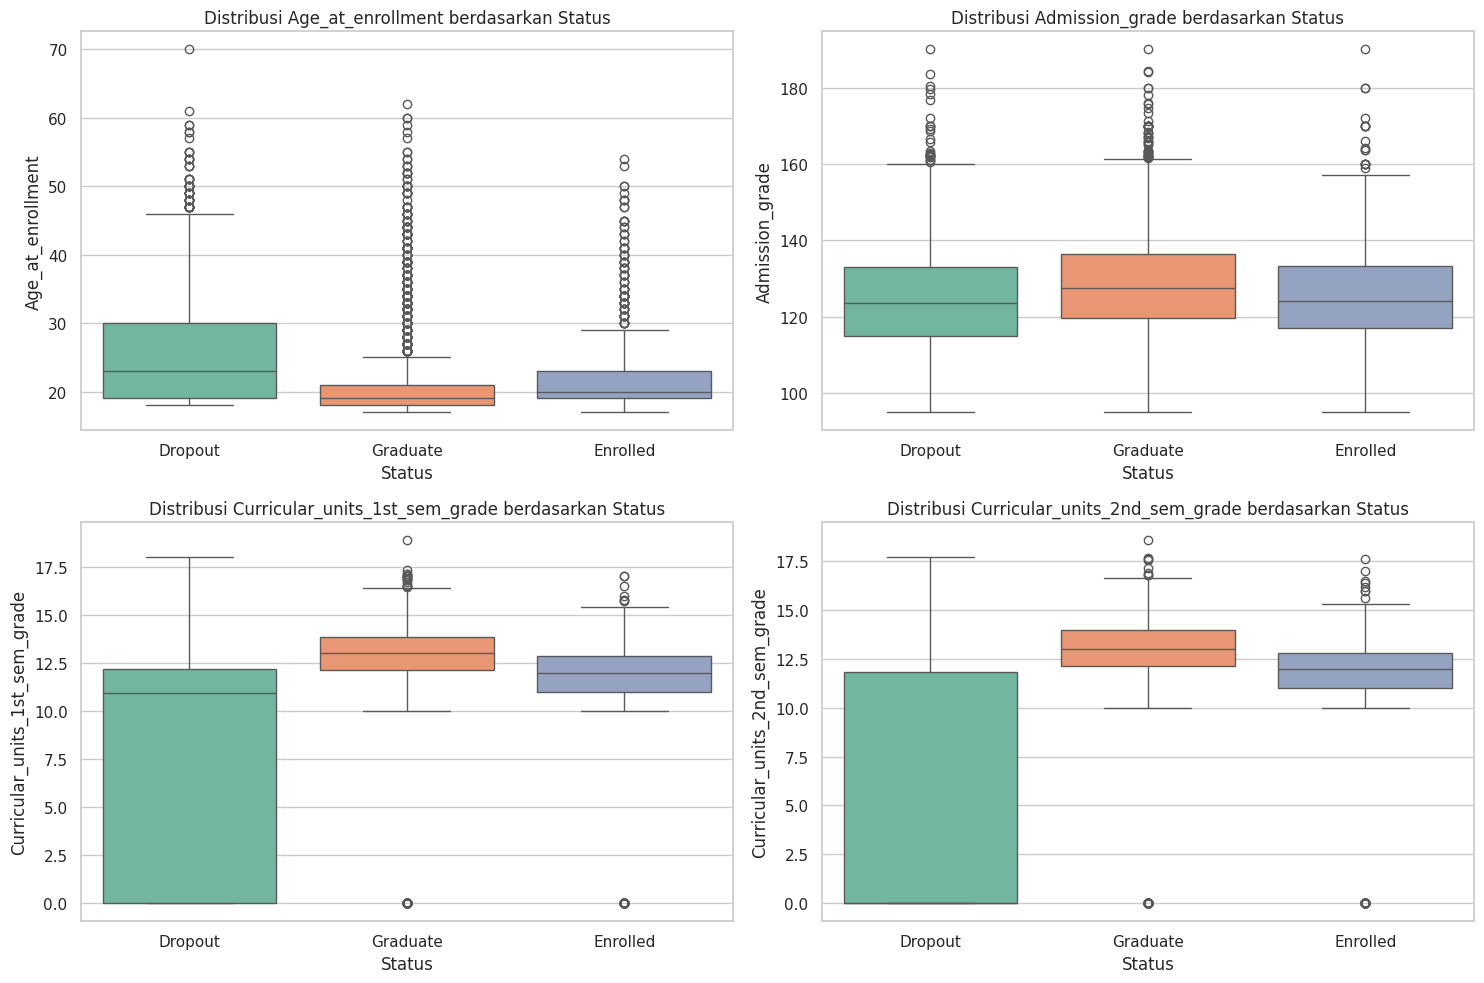

In [12]:
# Daftar kolom numerik penting
num_cols = ['Age_at_enrollment', 'Admission_grade',
            'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Status', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Distribusi {col} berdasarkan Status', fontsize=12)

plt.tight_layout()
plt.show()

Melalui visualisasi *boxplot* di atas, kita dapat mengamati sebaran data numerik terkait usia dan performa akademik mahasiswa berdasarkan status akhir mereka. Dari segi usia saat mendaftar, terlihat bahwa mahasiswa yang mengalami *dropout* rata-rata memiliki rentang usia yang lebih tua dibandingkan dengan mahasiswa yang berhasil lulus. Hal ini bisa menjadi indikasi bahwa mahasiswa non-tradisional atau yang mendaftar di usia lebih dewasa mungkin menghadapi tantangan yang lebih besar, baik dari sisi adaptasi akademik maupun pembagian waktu dengan tanggung jawab lain di luar kampus. Sementara itu, pada aspek nilai pendaftaran awal (*admission grade*), perbedaannya tidak terlalu drastis antar kelompok, meskipun mahasiswa yang lulus cenderung memiliki nilai tengah yang sedikit lebih tinggi.

Namun, indikator yang paling mencolok dan menjadi prediktor terkuat dari visualisasi ini adalah performa akademik pada semester pertama dan kedua. Terlihat sangat jelas bahwa mahasiswa yang *dropout* memiliki rata-rata nilai semester satu dan dua yang jauh lebih rendah, bahkan banyak yang sebaran nilainya menyentuh angka nol atau anjlok drastis. Sebaliknya, mahasiswa yang berhasil lulus atau masih aktif kuliah menunjukkan distribusi nilai yang tinggi dan sangat konsisten di kedua semester tersebut. Temuan ini menegaskan bahwa kesulitan atau kegagalan akademik di tahun pertama kuliah adalah sinyal bahaya awal yang sangat kuat untuk memprediksi potensi *dropout*, sehingga pihak kampus seharusnya menjadikan nilai semester pertama sebagai alarm untuk segera memberikan intervensi atau bimbingan akademik khusus.

### Analisis Multivariat: Korelasi Performa Akademik Semester 1 dan Semester 2

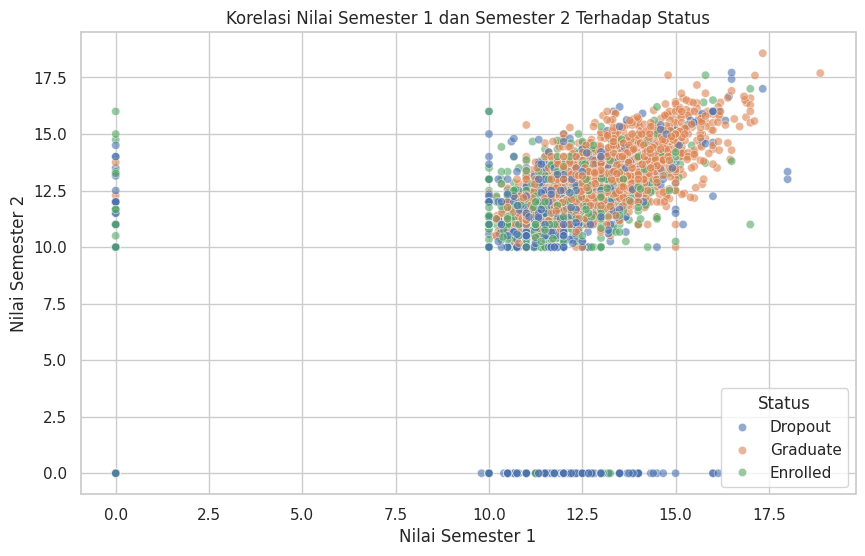

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,
                x='Curricular_units_1st_sem_grade',
                y='Curricular_units_2nd_sem_grade',
                hue='Status', palette='deep', alpha=0.6)
plt.title('Korelasi Nilai Semester 1 dan Semester 2 Terhadap Status')
plt.xlabel('Nilai Semester 1')
plt.ylabel('Nilai Semester 2')
plt.show()

Visualisasi *scatter plot* di atas memperlihatkan hubungan langsung antara nilai rata-rata yang diperoleh mahasiswa pada semester pertama dengan pencapaian mereka di semester kedua. Terdapat pola korelasi positif yang sangat kuat membentuk garis diagonal, di mana mahasiswa yang meraih nilai baik di awal perkuliahan cenderung mampu mempertahankan performanya tersebut di semester berikutnya. Jika diamati berdasarkan pengelompokan status akhirnya, terlihat jelas bahwa kelompok mahasiswa yang berhasil lulus berkumpul dengan padat di kuadran kanan atas berkat perolehan nilai yang tinggi dan konsisten.

Sebaliknya, titik-titik penyebaran yang mewakili mahasiswa *dropout* sebagian besar menumpuk dan tertinggal di area sudut kiri bawah, dengan nilai yang mendekati atau bahkan menyentuh angka nol pada kedua semester. Terdapat juga beberapa pola di mana nilai mahasiswa merosot tajam dari semester satu ke semester dua yang berujung pada status *dropout*. Pola visual ini secara nyata memvalidasi dugaan sebelumnya bahwa tren kegagalan akademik yang dibiarkan tanpa penanganan sejak tahun pertama merupakan faktor determinan paling kuat yang berujung pada terhentinya masa studi mahasiswa di Jaya Jaya Institut.

### Analisis Multivariat: Pengaruh Kondisi Ekonomi Makro terhadap Status Mahasiswa

/tmp/ipykernel_8802/2418523779.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y=col, palette='coolwarm', ax=axes[i])
/tmp/ipykernel_8802/2418523779.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y=col, palette='coolwarm', ax=axes[i])
/tmp/ipykernel_8802/2418523779.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y=col, palette='coolwarm', ax=axes[i])


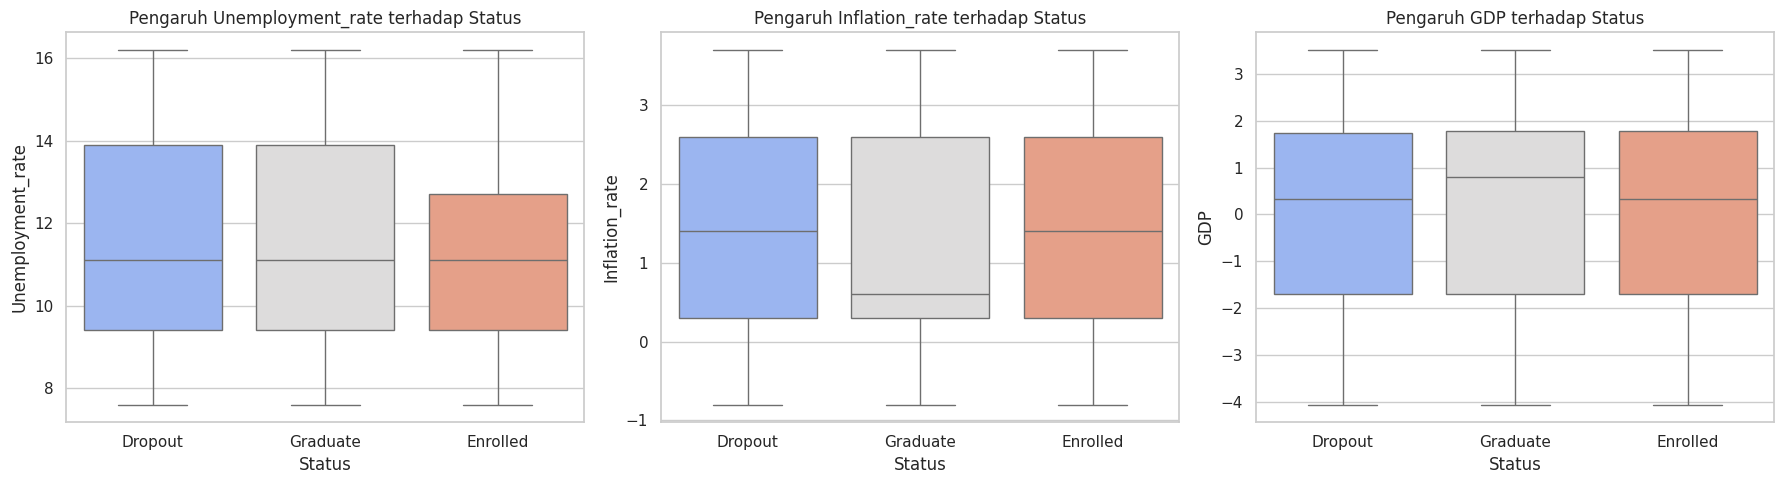

In [14]:
macro_cols = ['Unemployment_rate', 'Inflation_rate', 'GDP']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, col in enumerate(macro_cols):
    sns.boxplot(data=df, x='Status', y=col, palette='coolwarm', ax=axes[i])
    axes[i].set_title(f'Pengaruh {col} terhadap Status', fontsize=12)

plt.tight_layout()
plt.show()

Visualisasi *boxplot* di atas mengeksplorasi potensi pengaruh kondisi ekonomi eksternal—yakni tingkat pengangguran, laju inflasi, dan Produk Domestik Bruto (PDB)—terhadap probabilitas kelulusan mahasiswa. Menariknya, berbeda dengan faktor akademik dan finansial pribadi yang sebelumnya menunjukkan pola kontras, ketiga indikator makroekonomi ini menampilkan sebaran data yang sangat identik dan merata di seluruh kelompok status mahasiswa. Titik tengah (*median*) serta rentang data pada setiap kotak tidak memperlihatkan pergeseran atau perbedaan yang signifikan antara mahasiswa yang lulus, masih aktif, maupun yang mengalami *dropout*. Temuan ini mengindikasikan bahwa fluktuasi ekonomi di tingkat makro pada rentang waktu tersebut tidak memberikan dampak langsung yang krusial terhadap keberlangsungan studi mahasiswa. Dengan kata lain, akar permasalahan tingginya angka *dropout* di Jaya Jaya Institut murni didorong oleh faktor-faktor internal pada level individu, seperti performa nilai yang buruk dan ketidaksiapan finansial personal, bukan karena tekanan iklim ekonomi secara luas.

### Analisis Bivariat: Distribusi Latar Belakang Pendidikan dan Pekerjaan Orang Tua

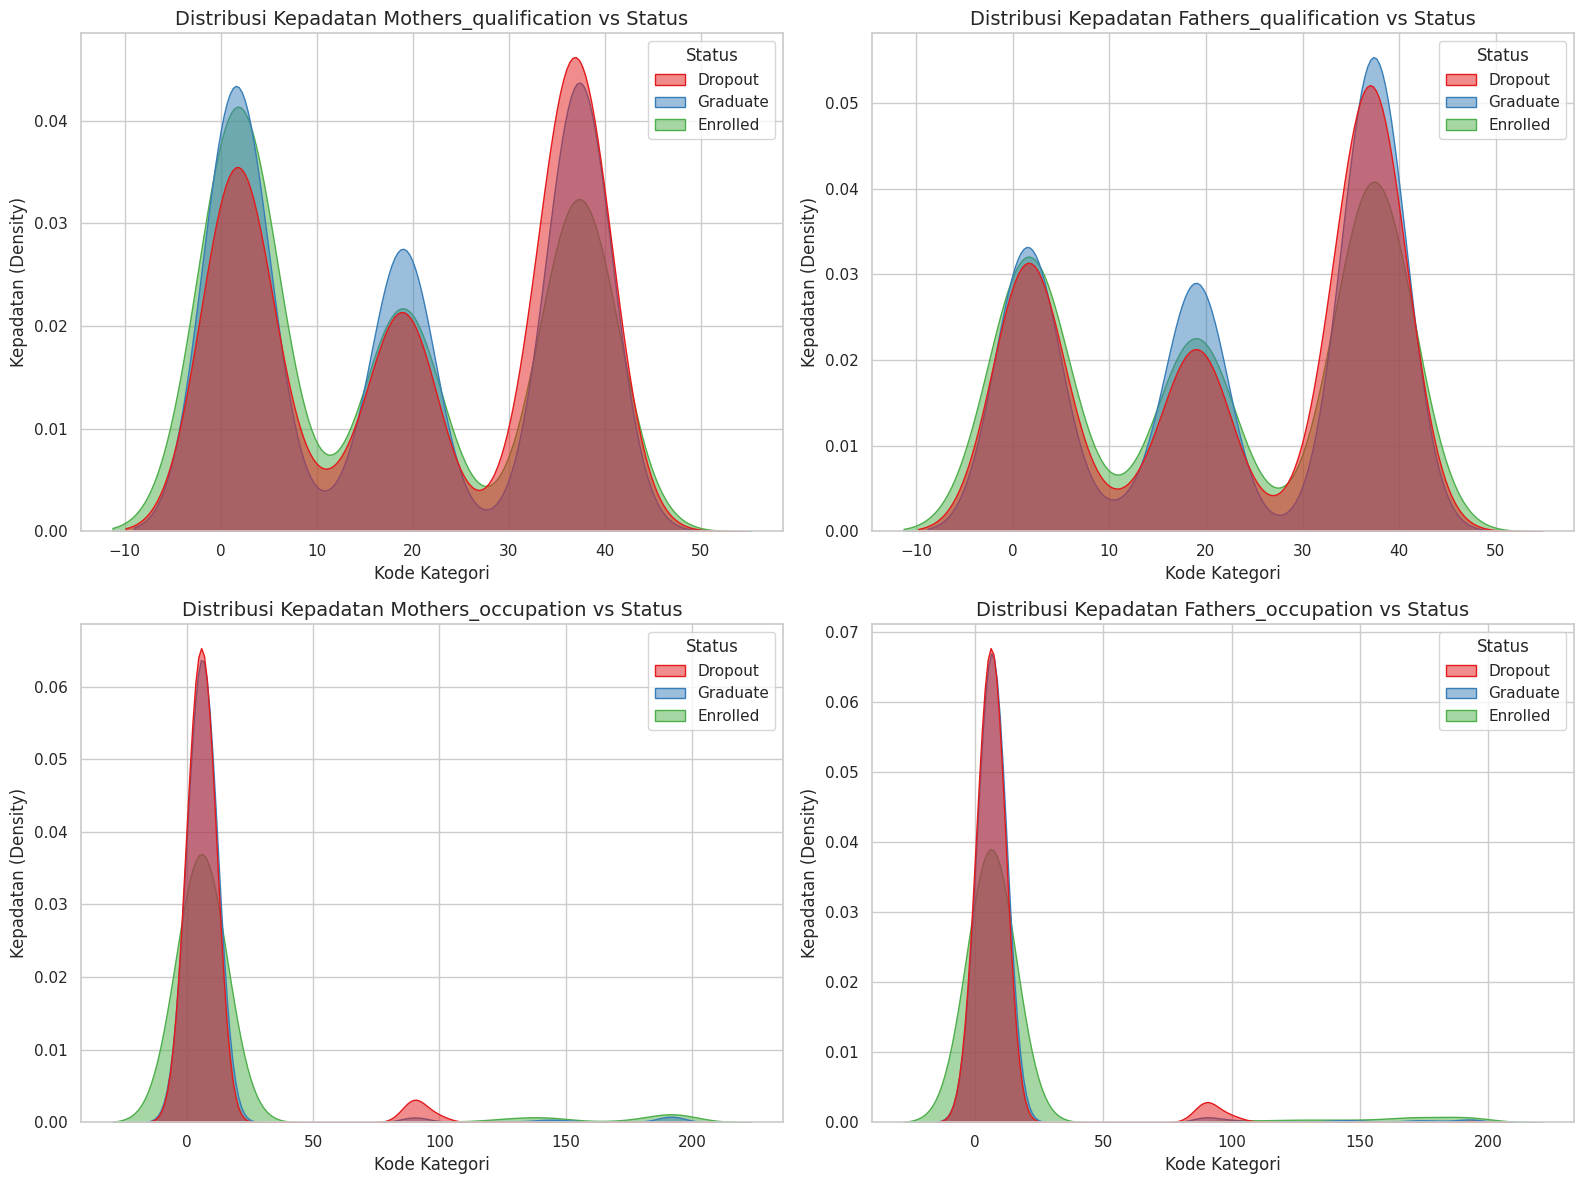

In [15]:
# Daftar kolom latar belakang keluarga
family_cols = ['Mothers_qualification', 'Fathers_qualification',
               'Mothers_occupation', 'Fathers_occupation']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(family_cols):
    # Menggunakan KDE plot untuk melihat kepadatan (konsentrasi) data
    sns.kdeplot(data=df, x=col, hue='Status', fill=True, palette='Set1', ax=axes[i], common_norm=False, alpha=0.5)
    axes[i].set_title(f'Distribusi Kepadatan {col} vs Status', fontsize=14)
    axes[i].set_xlabel('Kode Kategori')
    axes[i].set_ylabel('Kepadatan (Density)')

plt.tight_layout()
plt.show()

Visualisasi *KDE (Kernel Density Estimate) plot* di atas memperlihatkan kepadatan profil latar belakang keluarga mahasiswa, yang mencakup tingkat kualifikasi pendidikan dan bidang pekerjaan dari ayah maupun ibu. Secara umum, kurva kepadatan untuk ketiga kelompok status akhir mahasiswa tampak saling tumpang tindih secara signifikan di hampir seluruh kode kategori. Hal ini menunjukkan bahwa latar belakang pendidikan maupun jenis profesi orang tua tidak menjadi pembeda yang mutlak atau faktor penentu utama dalam keberhasilan maupun kegagalan studi mahasiswa di Jaya Jaya Institut. Meskipun terdapat beberapa puncak lonjakan konsentrasi pada kode kategori tertentu, dampaknya cenderung bias dan tidak sekuat faktor kesiapan finansial pribadi serta performa akademik yang telah dianalisis sebelumnya. Oleh karena itu, latar belakang keluarga lebih tepat diposisikan sebagai variabel pendukung atau sekunder alih-alih sebagai akar permasalahan utama dari tingginya angka *dropout* di institusi ini.

## Data Preparation / Preprocessing

### Cek Missing Value dan Duplikat

In [16]:
df_clean = df.drop_duplicates()
df_clean = df_clean.dropna()
print(f"Bentuk data setelah pembersihan: {df_clean.shape}")

Bentuk data setelah pembersihan: (4424, 37)


### Membuang kolom yang redundan (korelasi > 0.85)

In [17]:
corr_matrix = df_clean.drop(columns=['Status']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [18]:
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print(f"Kolom yang saling tumpang tindih dan akan dibuang: {to_drop}")

Kolom yang saling tumpang tindih dan akan dibuang: ['Fathers_occupation', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved']


In [19]:
df_clean = df_clean.drop(columns=to_drop)

### Labeling

In [20]:
encoder = LabelEncoder()
df_clean['Status_encoded'] = encoder.fit_transform(df_clean['Status'])
print("Mapping Label Status:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

Mapping Label Status: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


### Memisah Fitur (X) dengan Target (y)

In [21]:
X = df_clean.drop(columns=['Status', 'Status_encoded'])
y = df_clean['Status_encoded']

# Membagi data (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Standarisasi Skala

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
print("Jumlah Data Latih:", X_train_scaled.shape[0])
print("Jumlah Data Uji:", X_test_scaled.shape[0])
print("Jumlah Fitur Akhir yang Digunakan:", X_train_scaled.shape[1])

Jumlah Data Latih: 3539
Jumlah Data Uji: 885
Jumlah Fitur Akhir yang Digunakan: 32


## Modeling

Pada tahap pemodelan ini, tiga algoritma yang digunakan berbasis *Ensemble Tree* (Pohon Keputusan). Alasan utamanya adalah algoritma ini sangat tangguh terhadap data yang memiliki korelasi antar-fitur (*multicollinearity*).

Berikut adalah tiga model yang akan dilatih dan diuji menggunakan *Hyperparameter Tuning* (`BayesSearchCV`):

1. **Random Forest:** Model ini bekerja dengan membangun ratusan "pohon keputusan" secara acak dan mengambil keputusan berdasarkan suara terbanyak (*majority voting*). Model ini dipilih karena sangat stabil, minim risiko *overfitting*, dan sangat kebal terhadap *outlier* (pencilan) pada data gaji atau umur karyawan.
2. **Gradient Boosting:** Berbeda dengan Random Forest yang membangun pohon secara paralel, model ini membangun pohon secara berurutan (*sequential*). Setiap pohon baru yang dibangun akan secara spesifik fokus untuk "memperbaiki kesalahan" tebakan dari pohon sebelumnya. Sangat cocok untuk menangkap pola rumit alasan karyawan *resign*.
3. **XGBoost (Extreme Gradient Boosting):** Merupakan versi *upgrade* dan modern dari Gradient Boosting. XGBoost dipilih karena proses pelatihannya yang jauh lebih cepat dan memiliki fitur *regularization* (pinalti) bawaan yang sangat efektif untuk mencegah model menghafal data (*overfitting*).

### Random Forest

In [24]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    )

In [25]:
search_spaces = {
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 20),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 4)
}

In [26]:
bayes_search = BayesSearchCV(
    estimator=rf,
    search_spaces=search_spaces,
    n_iter=30,
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42,
)

In [27]:
bayes_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

BayesSearchCV(cv=5,
              estimator=RandomForestClassifier(class_weight='balanced',
                                               random_state=42),
              n_iter=30, n_jobs=-1, random_state=42,
              search_spaces={'max_depth': Integer(low=1, high=20, prior='uniform', transform='normalize'),
                             'min_samples_leaf': Integer(low=1, high=4, prior='uniform', transform='normalize'),
                             'min_samples_split': Integer(low=2, high=10, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=50, high=200, prior='uniform', transform='normalize')},
              verbose=2)

In [28]:
best_rf_model = bayes_search.best_estimator_

### Gradient Boosting

In [29]:
class_counts = y_train.value_counts()
total_samples = len(y_train)
num_classes = len(class_counts)

class_weights_dict = {
    0: total_samples / (num_classes * class_counts[0]),
    1: total_samples / (num_classes * class_counts[1]),
    2: total_samples / (num_classes * class_counts[2])
}

# Memetakan (map) ke y_train
sample_weights = y_train.map(class_weights_dict)

print("Bobot kelas yang dihitung:", class_weights_dict)
print("Contoh sample_weights untuk data training:")
print(sample_weights.head())

Bobot kelas yang dihitung: {0: np.float64(1.0375256523013778), 1: np.float64(1.857742782152231), 2: np.float64(0.6676098849273722)}
Contoh sample_weights untuk data training:
2283    0.667610
3874    1.037526
2281    1.857743
817     0.667610
404     0.667610
Name: Status_encoded, dtype: float64


In [30]:
gb = GradientBoostingClassifier(random_state=42)

In [31]:
search_spaces_gb = {
    'n_estimators': Integer(50, 200),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 4)
}

In [32]:
opt_gb = BayesSearchCV(
    estimator=gb,
    search_spaces=search_spaces_gb,
    n_iter=30,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

In [34]:
opt_gb.fit(X_train_scaled, y_train, sample_weight=sample_weights)

BayesSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
              n_iter=30, n_jobs=-1, random_state=42,
              search_spaces={'learning_rate': Real(low=0.01, high=0.2, prior='log-uniform', transform='normalize'),
                             'max_depth': Integer(low=3, high=10, prior='uniform', transform='normalize'),
                             'min_samples_leaf': Integer(low=1, high=4, prior='uniform', transform='normalize'),
                             'min_samples_split': Integer(low=2, high=10, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=50, high=200, prior='uniform', transform='normalize')})

In [35]:
best_gb_model = opt_gb.best_estimator_

### XGBoost

In [36]:
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Nilai Scale Pos Weight: {ratio:.2f}")

Nilai Scale Pos Weight: 1.79


In [37]:
xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

In [38]:
search_spaces_xgb = {
    'n_estimators': Integer(50, 300),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'min_child_weight': Integer(1, 10),
    'gamma': Real(0, 0.5),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0)
}

In [39]:
opt_xgb = BayesSearchCV(
    estimator=xgb_clf,
    search_spaces=search_spaces_xgb,
    n_iter=30,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [40]:
opt_xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

BayesSearchCV(cv=5,
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None, device=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False,
                                      eval_metric='mlogloss',
                                      feature_types=None, feature_weights=None,
                                      gamma=None, grow_policy=None,
                                      importance_type=None,
                                      interaction_constrai...
                             'learning_rate': Real(low=0.01, high=0.3, prior='log-uniform', transform='normalize'),
                             'max_depth': Integer(low=3, high=10, prior='uniform', transform='normalize'),
                             'min_child_weight': Integer(low=1, high=10, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=50, high=300, prior='uniform', transform='normalize'),
                             'subsample': Real(low=0.6, high=1.0, prior='uniform', transform='normalize')},
              verbose=1)

In [41]:
best_xgb_model = opt_xgb.best_estimator_

## Evaluation

In [42]:
y_pred_rf = best_rf_model.predict(X_test_scaled)
y_pred_gb = best_gb_model.predict(X_test_scaled)
y_pred_xgb = best_xgb_model.predict(X_test_scaled)

### Random Forest

In [43]:
accuracy_score(y_test, y_pred_rf)

0.7502824858757062

In [44]:
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.74      0.76       284
           1       0.51      0.39      0.44       159
           2       0.79      0.89      0.83       442

    accuracy                           0.75       885
   macro avg       0.70      0.67      0.68       885
weighted avg       0.74      0.75      0.74       885



Text(0.5, 1.0, 'Confusion Matrix - Random Forest')

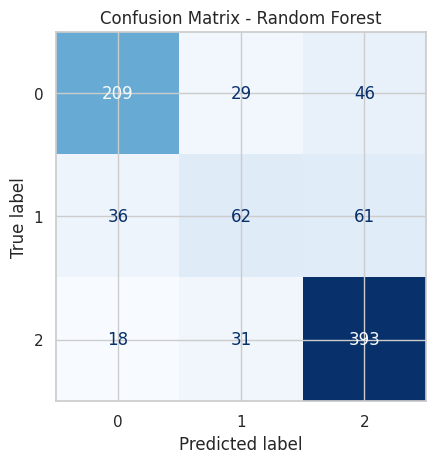

In [45]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues', colorbar=False)
disp.ax_.set_title("Confusion Matrix - Random Forest")

### Gradient Boosting

In [46]:
accuracy_score(y_test, y_pred_gb)

0.7423728813559322

In [47]:
print("Classification Report:\n", classification_report(y_test, y_pred_gb))

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.72      0.75       284
           1       0.46      0.42      0.44       159
           2       0.80      0.88      0.83       442

    accuracy                           0.74       885
   macro avg       0.68      0.67      0.68       885
weighted avg       0.74      0.74      0.74       885



Text(0.5, 1.0, 'Confusion Matrix - Gradient Boosting')

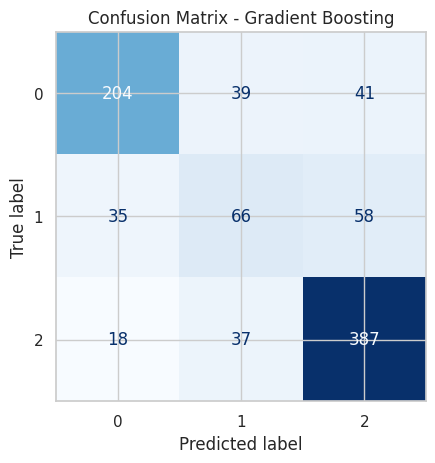

In [48]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, cmap='Blues', colorbar=False)
disp.ax_.set_title("Confusion Matrix - Gradient Boosting")

### XGBoost

In [49]:
accuracy_score(y_test, y_pred_xgb)

0.735593220338983

In [50]:
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.69      0.75       284
           1       0.44      0.57      0.50       159
           2       0.83      0.82      0.83       442

    accuracy                           0.74       885
   macro avg       0.69      0.70      0.69       885
weighted avg       0.76      0.74      0.74       885



Text(0.5, 1.0, 'Confusion Matrix - XGBoost ')

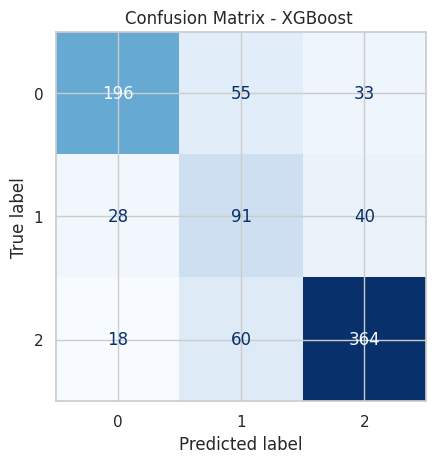

In [51]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap='Blues', colorbar=False)
disp.ax_.set_title("Confusion Matrix - XGBoost ")

## Menyimpan Model Terbaik

In [52]:
# Tentukan path folder di Google Drive
folder_path = '/content/drive/MyDrive/Proyek Student Performance Submission Kedua [Dicoding]/model/'

joblib.dump(best_xgb_model, folder_path + 'xgb_model.pkl')
joblib.dump(scaler, folder_path + 'scaler.pkl')
joblib.dump(encoder, folder_path + 'encoder.pkl')

print("Model berhasil disimpan!")

Model berhasil disimpan!


## Menyimpan Dataset Awal dengan Mapping

In [53]:
folder_path_2 = '/content/drive/MyDrive/Proyek Student Performance Submission Kedua [Dicoding]/'

In [54]:
df_dashboard = df_clean.copy()

# 1. Mapping Variabel Biner & Sederhana
df_dashboard['Gender'] = df_dashboard['Gender'].map({1: 'Laki-laki', 0: 'Perempuan'})
df_dashboard['Scholarship_holder'] = df_dashboard['Scholarship_holder'].map({1: 'Punya Beasiswa', 0: 'Tidak Punya'})
df_dashboard['Tuition_fees_up_to_date'] = df_dashboard['Tuition_fees_up_to_date'].map({1: 'Lancar', 0: 'Menunggak'})
df_dashboard['Debtor'] = df_dashboard['Debtor'].map({1: 'Berutang', 0: 'Tidak Berutang'})
df_dashboard['Displaced'] = df_dashboard['Displaced'].map({1: 'Pendatang', 0: 'Warga Lokal'})
df_dashboard['Daytime_evening_attendance'] = df_dashboard['Daytime_evening_attendance'].map({1: 'Kelas Siang', 0: 'Kelas Malam'})
df_dashboard['International'] = df_dashboard['International'].map({1: 'Ya', 0: 'Tidak'})
df_dashboard['Educational_special_needs'] = df_dashboard['Educational_special_needs'].map({1: 'Ya', 0: 'Tidak'})

# 2. Mapping Status Pernikahan
df_dashboard['Marital_status'] = df_dashboard['Marital_status'].map({
    1: 'Belum Menikah', 2: 'Menikah', 3: 'Duda/Janda (Mati)',
    4: 'Bercerai', 5: 'Kumpul Kebo', 6: 'Berpisah Sah'
})

# 3. Mapping Program Studi (Course)
df_dashboard['Course'] = df_dashboard['Course'].map({
    33: 'Teknologi Produksi Biofuel', 171: 'Desain Animasi & Multimedia',
    8014: 'Layanan Sosial (Malam)', 9003: 'Agronomi', 9070: 'Desain Komunikasi',
    9085: 'Keperawatan Hewan', 9119: 'Teknik Informatika', 9130: 'Kuda & Berkuda',
    9147: 'Manajemen', 9238: 'Layanan Sosial', 9254: 'Pariwisata',
    9500: 'Keperawatan', 9556: 'Kebersihan Gigi', 9670: 'Manajemen Periklanan',
    9773: 'Jurnalisme & Komunikasi', 9853: 'Pendidikan Dasar', 9991: 'Manajemen (Malam)'
})

# 4. Mapping Kewarganegaraan (Nacionality)
df_dashboard['Nacionality'] = df_dashboard['Nacionality'].map({
    1: 'Portugis', 2: 'Jerman', 6: 'Spanyol', 11: 'Italia', 13: 'Belanda',
    14: 'Inggris', 17: 'Lituania', 21: 'Angola', 22: 'Tanjung Verde',
    24: 'Guinea', 25: 'Mozambik', 26: 'Sao Tome', 32: 'Turki', 41: 'Brasil',
    62: 'Rumania', 100: 'Moldova', 101: 'Meksiko', 103: 'Ukraina',
    105: 'Rusia', 108: 'Kuba', 109: 'Kolombia'
}).fillna('Lainnya')

# 5. Mapping Mode Pendaftaran (Application Mode)
df_dashboard['Application_mode'] = df_dashboard['Application_mode'].map({
    1: 'Fase 1 - Umum', 2: 'Ordinance 612/93', 5: 'Fase 1 - Khusus (Azores)',
    7: 'Lulusan PT Lain', 10: 'Ordinance 854-B/99', 15: 'Mahasiswa Internasional',
    16: 'Fase 1 - Khusus (Madeira)', 17: 'Fase 2 - Umum', 18: 'Fase 3 - Umum',
    26: 'Ordinance 533-A/99 (B2)', 27: 'Ordinance 533-A/99 (B3)', 39: 'Usia > 23 Tahun',
    42: 'Transfer', 43: 'Pindah Jurusan', 44: 'Diploma Spesialisasi Teknologi',
    51: 'Pindah Kampus/Jurusan', 53: 'Diploma Siklus Pendek', 57: 'Pindah Kampus Internasional'
}).fillna('Jalur Lainnya')

# 6. Mapping Pendidikan Sebelumnya (Previous Qualification)
df_dashboard['Previous_qualification'] = df_dashboard['Previous_qualification'].map({
    1: 'Pendidikan Menengah', 2: 'Sarjana (S1)', 3: 'Gelar Pendidikan Tinggi',
    4: 'Magister (S2)', 5: 'Doktor (S3)', 6: 'Pernah Kuliah',
    9: 'Kelas 12 (Tidak Tamat)', 10: 'Kelas 11 (Tidak Tamat)', 12: 'Lainnya - Kelas 11',
    14: 'Kelas 10', 15: 'Kelas 10 (Tidak Tamat)', 19: 'Pend. Dasar 3',
    38: 'Pend. Dasar 2', 39: 'Spesialisasi Teknologi', 40: 'Sarjana (S1)',
    42: 'Kursus Teknis Prof.', 43: 'Magister (S2)'
}).fillna('Lainnya')

# 7. Translasi Nama Kolom (Header) ke Bahasa Indonesia
rename_dict = {
    'Marital_status': 'Status Pernikahan', 'Application_mode': 'Jalur Pendaftaran',
    'Application_order': 'Urutan Pilihan Prodi', 'Course': 'Program Studi',
    'Daytime_evening_attendance': 'Waktu Kuliah', 'Previous_qualification': 'Pend. Sebelumnya',
    'Previous_qualification_grade': 'Nilai Pend. Sebelumnya', 'Nacionality': 'Kewarganegaraan',
    'Mothers_qualification': 'Pendidikan Ibu (Kode)', 'Fathers_qualification': 'Pendidikan Ayah (Kode)',
    'Mothers_occupation': 'Pekerjaan Ibu (Kode)', 'Fathers_occupation': 'Pekerjaan Ayah (Kode)',
    'Admission_grade': 'Nilai Masuk', 'Displaced': 'Status Pendatang',
    'Educational_special_needs': 'Kebutuhan Khusus Pend.', 'Debtor': 'Status Utang',
    'Tuition_fees_up_to_date': 'Status Pembayaran SPP', 'Gender': 'Jenis Kelamin',
    'Scholarship_holder': 'Penerima Beasiswa', 'Age_at_enrollment': 'Usia Saat Mendaftar',
    'International': 'Mahasiswa Internasional', 'Curricular_units_1st_sem_credited': 'SKS Diakui (Sem 1)',
    'Curricular_units_1st_sem_enrolled': 'SKS Diambil (Sem 1)', 'Curricular_units_1st_sem_evaluations': 'Jumlah Evaluasi (Sem 1)',
    'Curricular_units_1st_sem_approved': 'SKS Lulus (Sem 1)', 'Curricular_units_1st_sem_grade': 'Rata-rata Nilai Sem 1',
    'Curricular_units_1st_sem_without_evaluations': 'SKS Tanpa Evaluasi (Sem 1)', 'Curricular_units_2nd_sem_credited': 'SKS Diakui (Sem 2)',
    'Curricular_units_2nd_sem_enrolled': 'SKS Diambil (Sem 2)', 'Curricular_units_2nd_sem_evaluations': 'Jumlah Evaluasi (Sem 2)',
    'Curricular_units_2nd_sem_approved': 'SKS Lulus (Sem 2)', 'Curricular_units_2nd_sem_grade': 'Rata-rata Nilai Sem 2',
    'Curricular_units_2nd_sem_without_evaluations': 'SKS Tanpa Evaluasi (Sem 2)', 'Unemployment_rate': 'Tingkat Pengangguran',
    'Inflation_rate': 'Tingkat Inflasi', 'GDP': 'PDB', 'Status': 'Status Akhir'
}
df_dashboard_final = df_dashboard.rename(columns=rename_dict)
df_dashboard_final

,Status Pernikahan,Jalur Pendaftaran,Urutan Pilihan Prodi,Program Studi,Waktu Kuliah,Pend. Sebelumnya,Nilai Pend. Sebelumnya,Kewarganegaraan,Pendidikan Ibu (Kode),Pendidikan Ayah (Kode),...,Rata-rata Nilai Sem 1,SKS Tanpa Evaluasi (Sem 1),Jumlah Evaluasi (Sem 2),Rata-rata Nilai Sem 2,SKS Tanpa Evaluasi (Sem 2),Tingkat Pengangguran,Tingkat Inflasi,PDB,Status Akhir,Status_encoded
0,Belum Menikah,Fase 2 - Umum,5,Desain Animasi & Multimedia,Kelas Siang,Pendidikan Menengah,122.0,Portugis,19,12,...,0.000000,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
1,Belum Menikah,Mahasiswa Internasional,1,Pariwisata,Kelas Siang,Pendidikan Menengah,160.0,Portugis,1,3,...,14.000000,0,6,13.666667,0,13.9,-0.3,0.79,Graduate,2
2,Belum Menikah,Fase 1 - Umum,5,Desain Komunikasi,Kelas Siang,Pendidikan Menengah,122.0,Portugis,37,37,...,0.000000,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
3,Belum Menikah,Fase 2 - Umum,2,Jurnalisme & Komunikasi,Kelas Siang,Pendidikan Menengah,122.0,Portugis,38,37,...,13.428571,0,10,12.400000,0,9.4,-0.8,-3.12,Graduate,2
4,Menikah,Usia > 23 Tahun,1,Layanan Sosial (Malam),Kelas Malam,Pendidikan Menengah,100.0,Portugis,37,38,...,12.333333,0,6,13.000000,0,13.9,-0.3,0.79,Graduate,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,Belum Menikah,Fase 1 - Umum,6,Jurnalisme & Komunikasi,Kelas Siang,Pendidikan Menengah,125.0,Portugis,1,1,...,13.600000,0,8,12.666667,0,15.5,2.8,-4.06,Graduate,2
4420,Belum Menikah,Fase 1 - Umum,2,Jurnalisme & Komunikasi,Kelas Siang,Pendidikan Menengah,120.0,Rusia,1,1,...,12.000000,0,6,11.000000,0,11.1,0.6,2.02,Dropout,0
4421,Belum Menikah,Fase 1 - Umum,1,Keperawatan,Kelas Siang,Pendidikan Menengah,154.0,Portugis,37,37,...,14.912500,0,9,13.500000,0,13.9,-0.3,0.79,Dropout,0
4422,Belum Menikah,Fase 1 - Umum,1,Manajemen,Kelas Siang,Pendidikan Menengah,180.0,Portugis,37,37,...,13.800000,0,6,12.000000,0,9.4,-0.8,-3.12,Graduate,2


In [55]:
df_dashboard_final.to_csv(folder_path_2 + 'Jaya_Jaya_Dashboard_Indo_Final.csv', index=False)